# <font color='blue'>Laplaciano em Grafos: Graph Embedding</font>

## Luis Gustavo Nonato  <br>
ICMC-USP

----

Considere um graph $G=(V,E,W)$. A ideia de _Graph Embedding_ é associar coordenadas aos vértices do grafo de modo que este possua uma representação geométrica em um espaço $\mathbb{R}^m$.

Quando $n=1$ o vetor de Fiedler (autovetor da Laplaciana associado ao menor autovalor não nulo) fornece um mapeamento do grafo $G$ sobre a reta real de modo que vértices conectados por arestas são mapeados tão próximos quanto possível na reta, ou seja, as coordenadas dos vértices são a solução do problema de minimização:

$$
\arg\min_{\mathbf{x}^\top \mathbf{D} \mathbf{x}=\mathbf{I}}\sum_{ij\in E}(x_i-x_j)^2w_{ij}
$$

onde $\mathbf{D}$ é a diagonal da Laplaciana de $G$.

A generalização do embedding na reta real para um espaço $\mathbb{R}^m$ pode ser obtida minimizando a função

$$
\arg\min_{\mathbf{X}^\top \mathbf{D} \mathbf{X}=\mathbf{I}}\sum_{ij\in E}\|\mathbf{x}_i-\mathbf{x}_j\|^2w_{ij}
$$

onde $\mathbf{x}_i\in \mathbb{R}^m$ corresponde as coordenadas do vértice $v_i$. Supondo que os pontos $\mathbf{x}_i$ são armazenadas como linhas de uma matriz $n\times m$ $\mathbf{X}$, temos que 

$$
\sum_{ij\in E}\|\mathbf{x}_i-\mathbf{x}_j\|^2w_{ij} = tr(\mathbf{X}^\top\mathbf{L}\mathbf{X})
$$

onde $L$ é a Laplaciana de $G$. A solução é portanto dada pelo $\mathbf{X}$ que minimiza

$$
\arg\min_{\mathbf{X}^\top \mathbf{D} \mathbf{X}=\mathbf{I}} = tr(\mathbf{X}^\top\mathbf{L}\mathbf{X})
$$

**OBS**: Além de contornar o problema de escala, a restrição $\mathbf{X}^\top \mathbf{D} \mathbf{X}=\mathbf{I}$, faz com que os pontos NÃO estejam em um subspaço de dimensão menor que $m$.

**Teorema**: A solução para o problema de minimização 

$$
\arg\min_{\mathbf{X}^\top \mathbf{D} \mathbf{X}=\mathbf{I}} = tr(\mathbf{X}^\top\mathbf{L}\mathbf{X})
$$

é dada quando as colunas de $\mathbf{X}$ são os autovetores associados aos menores autovalores não nulos do problema de autovalor generalizado

$$
\mathbf{L}\mathbf{x}= \lambda\mathbf{D}\mathbf{x}
$$

**Demonstração**: [veja seção 4 deste artigo](https://arxiv.org/pdf/1903.11240.pdf)

**Algoritmo**: Dado um grafo $G=(V,E,W)$
1. Calcular a matriz Laplaciana de $G$
2. Escolher a dimensão $m$ do espaço onde será realizado o embedding
3. Calcular $m+1$ autovetores associados aos menores autovalores dados como solução do problema de autovalor generalizado $\mathbf{L}\mathbf{x}= \lambda\mathbf{D}\mathbf{x}$
4. Armazenar os autovetores associados aos autovalores não nulos calculados no passo 3 como colunas de uma matriz $\mathbf{X}$
5. Cada linha de $\mathbf{X}$ corresponde a coordenada de um vértice.

Considerando apenas os $m$ autovetores associados aos menore autovalores não nulos, obtemos o embedding ótimo em $\mathbb{R}^m$.

In [1]:
import numpy as np
from scipy.sparse.linalg import eigsh
import networkx as ntx
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
A = np.loadtxt('del500.adj')
D = np.diag(np.sum(A,axis=1))
L = D - A

a, U = eigsh(L,k=3,M=D,which='SM')

In [3]:
print(A.shape)

(500, 500)


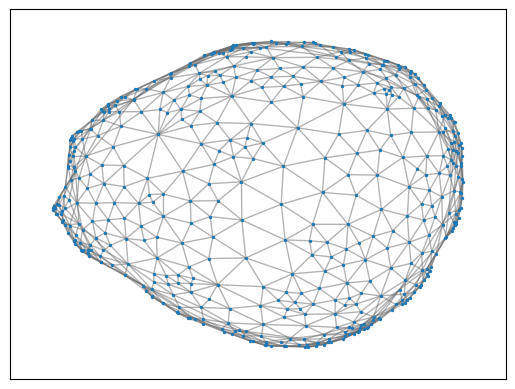

In [4]:
Gd = ntx.from_numpy_matrix(A)
ntx.draw_networkx_edges(Gd, pos=U[:,1:], edge_color='dimgray',alpha=0.5)
plt.scatter(U[:,1],U[:,2],s=2.0)

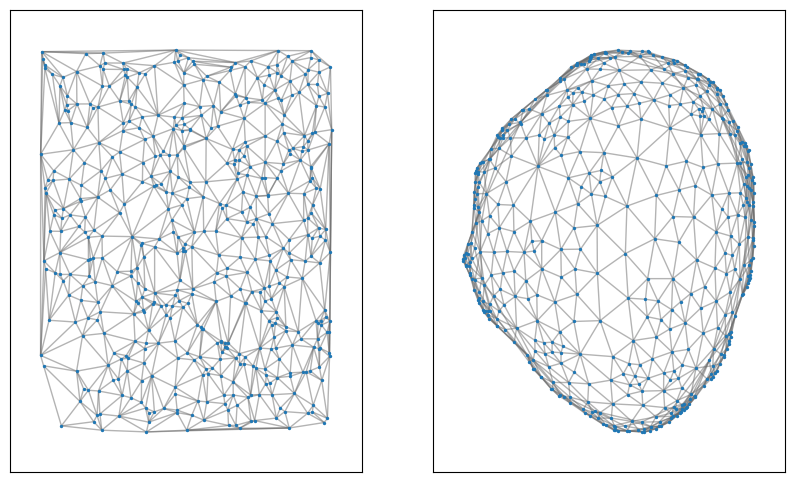

In [5]:
X = np.loadtxt('del500.xy')

f,(ax1,ax2) = plt.subplots(1,2,figsize=(10,6))
ntx.draw_networkx_edges(Gd, pos=X, edge_color='dimgray',alpha=0.5,ax=ax1)
ax1.scatter(X[:,0],X[:,1],s=2.0)
ntx.draw_networkx_edges(Gd, pos=U[:,1:], edge_color='dimgray',alpha=0.5,ax=ax2)
ax2.scatter(U[:,1],U[:,2],s=2.0)

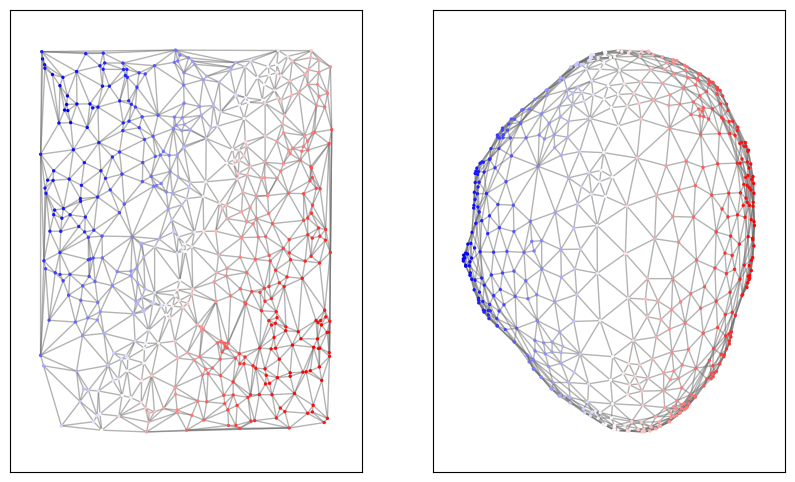

In [6]:
f,(ax1,ax2) = plt.subplots(1,2,figsize=(10,6))
ntx.draw_networkx_edges(Gd, pos=X, edge_color='dimgray',alpha=0.5,ax=ax1)
ax1.scatter(X[:,0],X[:,1],s=2.0,c=U[:,1],cmap='bwr')
ntx.draw_networkx_edges(Gd, pos=U[:,1:], edge_color='dimgray',alpha=0.5,ax=ax2)
ax2.scatter(U[:,1],U[:,2],s=2.0,c=U[:,1],cmap='bwr')

In [9]:
from scipy import sparse

ids = np.where((U[:,1]>-0.02) & (U[:,1]<0.02))[0]
# print(ids)

Aw = np.copy(A)

Aw[ids,:] = 2*Aw[ids,:]
Aw[:,ids] = 2*Aw[:,ids]
# print(np.all(np.abs(Aw-Aw.T) < 1.0e-7)) # verificando simetria

Dw = np.diag(np.sum(Aw,axis=1))
Lw = Dw - Aw

a, Uw = sparse.linalg.eigsh(Lw,k=3,M=Dw,which='SM')

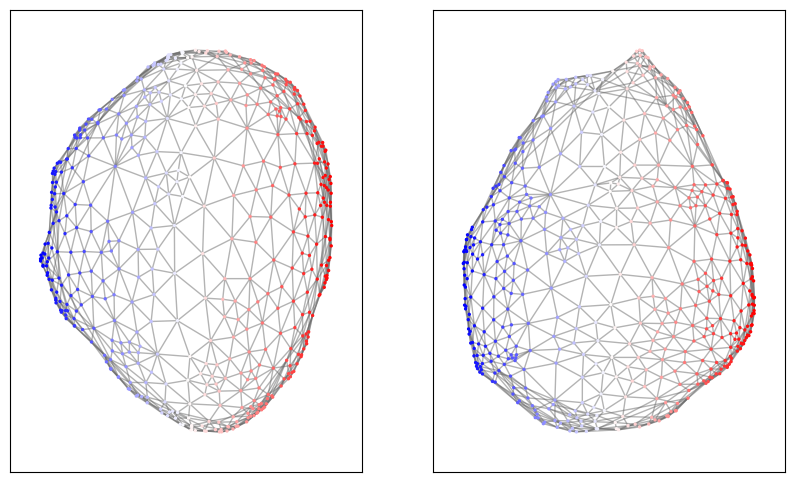

In [10]:
f,(ax1,ax2) = plt.subplots(1,2,figsize=(10,6))
ntx.draw_networkx_edges(Gd, pos=U[:,1:], edge_color='dimgray',alpha=0.5,ax=ax1)
ax1.scatter(U[:,1],U[:,2],s=2.0,c=U[:,1],cmap='bwr')
ntx.draw_networkx_edges(Gd, pos=Uw[:,1:], edge_color='dimgray',alpha=0.5,ax=ax2)
ax2.scatter(Uw[:,1],Uw[:,2],s=2.0,c=Uw[:,1],cmap='bwr')